## Predicting the market value of used cars
Rusty Bargain used car sales service is developing an app to attract new customers. In that app, you can quickly find out the market value of your car. 

I need to build a model to determine the value. I have access to historical data: technical specifications, trim versions, and prices.

Rusty Bargain is interested in:

- the quality of the prediction;
- the speed of the prediction;
- the time required for training

To develop this app, I will train, test, and compare the quality and speed of five models: Random Forest, Linear Regression, CatBoost, LightGBM, and XGBoost. I'll start by preparing and cleaning the dataset and doing some exploratory data analysis, and then will train and tune hyperparameters for the five models before performing final testing and comparison to recommend the best one for this use case.

In [2]:
# Load libraries
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from numpy.random import RandomState
import seaborn as sns
import matplotlib.pyplot as plt

## Data preparation
We'll start by taking a first look at the dataset.

In [3]:
# Load dataset
df = pd.read_csv('/datasets/car_data.csv')

# Call info and look at sample
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


The 'Price' column shows our target values in Euros. We can see that we are missing values in the 'VehicleType', 'Gearbox', 'Model', 'FuelType', and 'NotRepaired' feature columns, which we'll deal with in a moment.

It's immediately apparent that a few of these columns are not needed. We don't need the date that the profile was donloaded from the database ('DateCrawled'), the date the user created their profile ('DateCreated'), or the date of the last activity of the user ('LastSeen'). Additionally, the registration year could be useful as a proxy for the manufacture year since we don't have that data, but we don't need the vehicle registration month. First, we'll check for and drop any duplicate rows, and then we'll drop these columns.

Then, we'll take a look at the unique values in the remaining columns--it already looks like something strange might be going on with all zeroes in the 'NumberofPictures' column.

In [4]:
# Check for duplicates
df.duplicated().sum()

262

In [5]:
# Drop duplicates
df = df.drop_duplicates()

In [6]:
# Drop unnecessary columns
df.drop(['DateCreated', 'DateCrawled', 'LastSeen', 'RegistrationMonth'], axis=1, inplace=True)

# Look at unique values in remaining columns
for col in df.columns:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print()

Unique values in 'Price':
[  480 18300  9800 ... 12395 18429 10985]

Unique values in 'VehicleType':
[nan 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']

Unique values in 'RegistrationYear':
[1993 2011 2004 2001 2008 1995 1980 2014 1998 2005 1910 2016 2007 2009
 2002 2018 1997 1990 2017 1981 2003 1994 1991 1984 2006 1999 2012 2010
 2000 1992 2013 1996 1985 1989 2015 1982 1976 1983 1973 1111 1969 1971
 1987 1986 1988 1970 1965 1945 1925 1974 1979 1955 1978 1972 1968 1977
 1961 1960 1966 1975 1963 1964 5000 1954 1958 1967 1959 9999 1956 3200
 1000 1941 8888 1500 2200 4100 1962 1929 1957 1940 3000 2066 1949 2019
 1937 1951 1800 1953 1234 8000 5300 9000 2900 6000 5900 5911 1933 1400
 1950 4000 1948 1952 1200 8500 1932 1255 3700 3800 4800 1942 7000 1935
 1936 6500 1923 2290 2500 1930 1001 9450 1944 1943 1934 1938 1688 2800
 1253 1928 1919 5555 5600 1600 2222 1039 9996 1300 8455 1931 1915 4500
 1920 1602 7800 9229 1947 1927 7100 8200 1946 7500 3500]

Unique values in 'Gea

The 'NumberOfPictures' column has nothing but zeroes, so we'll drop that column as well.

There are a few other issues apparent here. First, there are several outlier / error values in the 'RegistrationYear' column, we'll need to drop any years that don't fall between 1900 and 2025. There are also zeroes in 'Power' which is impossible--horsepower would need to be at least 10. It also is extremely rare for horsepower to exceed 1,000. Finally, 'gasoline' and 'petrol' are the same thing, so those values should be combined.


In [7]:
# Drop 'NumberOfPictures' column
df.drop('NumberOfPictures', axis=1, inplace=True)

# Change 'petrol' to 'gasoline'
df['FuelType'] = df['FuelType'].replace('petrol', 'gasoline')

# Count outliers in RegistrationYear
count_invalid_years = ((df['RegistrationYear'] < 1900) | (df['RegistrationYear'] > 2025)).sum()
print('RegistrationYear outliers:', count_invalid_years)

# Count outliers in Power
count_invalid_hp= ((df['Power'] < 10) | (df['Power'] > 1000)).sum()
print('Power outliers:', count_invalid_hp)

RegistrationYear outliers: 171
Power outliers: 40740


There are very few 'RegistrationYear' outliers, so we can just drop those rows. However, there are a lot more 'Power' outliers, so it's worth taking a closer look at those.

In [8]:
# Drop RegistrationYear outliers
df = df[(df['RegistrationYear'] >= 1900) & (df['RegistrationYear'] <= 2025)]

# Look at 'Power' outliers
df['Power'].value_counts().sort_index()


0        40091
1           34
2           10
3            8
4           30
         ...  
17932        1
19208        1
19211        1
19312        1
20000        1
Name: Power, Length: 711, dtype: int64

The bulk of these outliers are zero values, and it's very likely that users input zero when they simply didn't know the horsepower. We can get rid of the rows with horsepower over 1,000 or between 1 and 10, and treat the zeroes as missing values to fill in.

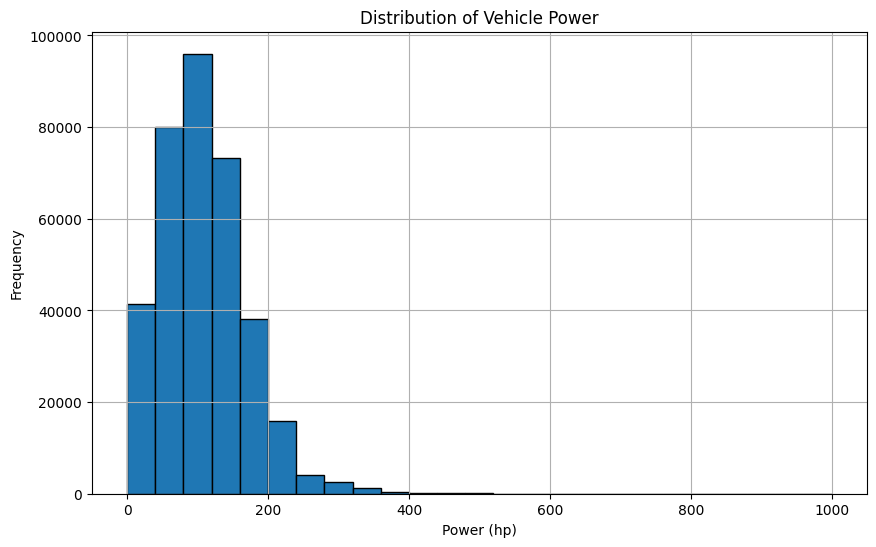

In [9]:
# Drop Power outliers
df = df[~((df['Power'] > 1000) | ((df['Power'] >= 1) & (df['Power'] < 10)))]

# Plot Power distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Power'], bins=25, edgecolor='black')
plt.title('Distribution of Vehicle Power')
plt.xlabel('Power (hp)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Since the distribution is right-skewed, we'll fill in the zeroes with the median.

In [10]:
# Replace zeroes with median
median_power = df.loc[df['Power'] != 0, 'Power'].median()
df.loc[df['Power'] == 0, 'Power'] = median_power

Now we have some missing values to deal with. We'll start by looking at the missing values in the 'VehicleType' and 'Model' columns.

In [11]:
# Display sample with missing values in 'VehicleType'
print("Missing in 'VehicleType':")
display(df[df['VehicleType'].isna()].sample(15))

# Display sample with missing values in 'Model'
print("Missing in 'Model':")
display(df[df['Model'].isna()].sample(15))

# Display sample with missing values in both columns
print("Missing in both 'VehicleType' and 'Model':")
display(df[df['VehicleType'].isna() & df['Model'].isna()].sample(15))

# Count numbers of rows missing values in both columns
missing_both_count = df[df['VehicleType'].isna() & df['Model'].isna()].shape[0]
print("Number of rows missing values in both 'VehicleType' and 'Model':", missing_both_count)

Missing in 'VehicleType':


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,FuelType,Brand,NotRepaired,PostalCode
161755,800,NaN,2016,manual,45.0,corsa,90000,NaN,opel,NaN,4895
249197,5850,NaN,2016,NaN,150.0,e_klasse,150000,NaN,mercedes_benz,no,13355
162877,0,NaN,2000,NaN,110.0,NaN,150000,NaN,sonstige_autos,NaN,17348
341908,1650,NaN,2000,NaN,75.0,fiesta,125000,NaN,ford,NaN,52525
152485,1299,NaN,2017,auto,193.0,NaN,150000,NaN,volkswagen,NaN,9517
346041,2750,NaN,2016,manual,114.0,x_trail,150000,gasoline,nissan,NaN,32547
75721,6750,NaN,2017,manual,116.0,1er,100000,NaN,bmw,no,13125
352234,1350,NaN,2016,manual,75.0,golf,150000,NaN,volkswagen,NaN,24837
117818,950,NaN,2017,NaN,110.0,NaN,150000,gasoline,opel,NaN,51377
18842,4800,NaN,2016,manual,110.0,5_reihe,150000,lpg,mazda,no,88299


Missing in 'Model':


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,FuelType,Brand,NotRepaired,PostalCode
50221,1650,small,2003,manual,55.0,NaN,150000,gasoline,fiat,NaN,91438
179600,750,NaN,2000,NaN,110.0,NaN,100000,NaN,toyota,NaN,9669
323682,699,NaN,2018,manual,60.0,NaN,150000,NaN,opel,no,44388
211362,6999,convertible,2008,manual,109.0,NaN,125000,gasoline,peugeot,NaN,59494
172699,1000,small,1997,manual,75.0,NaN,150000,gasoline,toyota,yes,84559
34135,0,NaN,2000,NaN,80.0,NaN,5000,NaN,volkswagen,NaN,22309
203090,4000,small,2002,manual,131.0,NaN,150000,gasoline,volkswagen,no,94545
233262,799,wagon,2003,NaN,155.0,NaN,150000,gasoline,opel,yes,18146
166044,50,NaN,1995,manual,110.0,NaN,150000,NaN,peugeot,NaN,30900
2496,8400,convertible,1979,manual,110.0,NaN,90000,gasoline,sonstige_autos,no,99096


Missing in both 'VehicleType' and 'Model':


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,FuelType,Brand,NotRepaired,PostalCode
342816,300,NaN,1995,manual,55.0,NaN,150000,NaN,hyundai,no,13585
46408,3999,NaN,2016,auto,197.0,NaN,150000,NaN,mercedes_benz,no,24148
149582,0,NaN,2005,NaN,110.0,NaN,100000,NaN,sonstige_autos,NaN,26389
167314,2600,NaN,2016,manual,110.0,NaN,100000,NaN,fiat,no,21073
25253,1,NaN,1995,NaN,110.0,NaN,10000,NaN,sonstige_autos,NaN,39104
248973,150,NaN,1995,NaN,110.0,NaN,150000,gasoline,renault,NaN,30539
158874,650,NaN,2016,manual,60.0,NaN,150000,NaN,citroen,no,48599
318250,189,NaN,1997,auto,100.0,NaN,150000,gasoline,citroen,NaN,10999
254250,2999,NaN,1990,manual,101.0,NaN,150000,gasoline,volkswagen,NaN,21279
132098,1300,NaN,2017,manual,110.0,NaN,150000,gasoline,hyundai,no,38642


Number of rows missing values in both 'VehicleType' and 'Model': 6733


The values appear to be missing at random. We can impute the model if we know the brand and vehicle type, and we can impute the vehicle type if we know the model. It's difficult to impute if we don't have either the vehicle type or the model, but only a small percentage (1.9%) of rows are missing both of those values so we'll just drop those.

In [12]:
# Drop rows missing values in both columns
df = df.dropna(subset=['VehicleType', 'Model'], how='all')

We'll start by filling in missing 'VehicleType' values with the mode vehicle type for that model.

In [13]:
# Compute the mode VehicleType for each Model group
vehicle_type_mode_by_model = df.groupby('Model')['VehicleType'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

# Define a function to fill missing VehicleType based on the mode for that Model
def fill_vehicle_type(row):
    if pd.isna(row['VehicleType']):
        return vehicle_type_mode_by_model.get(row['Model'], np.nan)
    return row['VehicleType']

# Apply the function
df['VehicleType'] = df.apply(fill_vehicle_type, axis=1)

In [14]:
# Check if missing values remain
df['VehicleType'].isna().sum()

0

All set on 'VehicleType'! Now we'll fill in the missing 'Model' values with the mode model for the brand and vehicle type.

In [15]:
def fill_model(row):
    if pd.isnull(row['Model']):
        # Try Brand + VehicleType
        group = df[(df['Brand'] == row['Brand']) & (df['VehicleType'] == row['VehicleType'])]
        mode_model = group['Model'].mode()
        
        if not mode_model.empty:
            return mode_model[0]
        else:
            # Fallback to Brand only
            group = df[df['Brand'] == row['Brand']]
            mode_model = group['Model'].mode()
            if not mode_model.empty:
                return mode_model[0]
    # Return original if not null or no fallback
    return row['Model']  

# Apply the function in place
df['Model'] = df.apply(fill_model, axis=1)


In [16]:
# Check if missing values remain
df['Model'].isna().sum()

2197

In [17]:
# Display sample with missing values in 'Model'
print("Missing in 'Model':")
display(df[df['Model'].isna()].sample(15))

Missing in 'Model':


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,FuelType,Brand,NotRepaired,PostalCode
121668,8900,sedan,2004,auto,279.0,NaN,150000,gasoline,sonstige_autos,no,78462
43470,19800,suv,2013,auto,264.0,NaN,70000,lpg,sonstige_autos,no,77966
239056,600,small,1996,manual,55.0,NaN,100000,gasoline,sonstige_autos,no,38678
126820,1,small,2000,NaN,110.0,NaN,150000,gasoline,sonstige_autos,NaN,50129
256685,8900,suv,2010,manual,156.0,NaN,70000,gasoline,sonstige_autos,no,32339
41431,17900,other,2000,NaN,110.0,NaN,100000,gasoline,sonstige_autos,NaN,88326
67771,2000,bus,1986,NaN,90.0,NaN,100000,gasoline,sonstige_autos,yes,28870
25509,6450,bus,2009,manual,126.0,NaN,125000,gasoline,sonstige_autos,no,23566
183581,9500,suv,2015,manual,50.0,NaN,5000,gasoline,sonstige_autos,no,84034
4539,15000,convertible,1980,manual,67.0,NaN,150000,gasoline,sonstige_autos,no,91781


In [18]:
# See which brands are missing Model values
missing_model_brands = df[df['Model'].isna()]['Brand'].unique()
print(missing_model_brands)

['sonstige_autos']


There are still some missing 'Model' values (indicating some Brand groups were missing 'Model' values for all observations) and they appear to all be from one brand: 'sonstige-autos'. Upon further research it looks like "sontige autos" is a German catchall term for "unknown" or "miscellaneous vehicle", so we can fill in these missing 'Model' values as 'other'.

In [19]:
# Fill in missing values with 'other'
df['Model'] = df['Model'].fillna('other')

Now we'll take a look at the missing values in the 'Gearbox' column.

In [20]:
# Display sample with missing values in 'Gearbox'
print("Missing in 'Gearbox':")
display(df[df['Gearbox'].isna()].sample(15))

Missing in 'Gearbox':


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,FuelType,Brand,NotRepaired,PostalCode
77010,8890,sedan,2017,NaN,140.0,a3,150000,gasoline,audi,NaN,77767
8672,1699,sedan,2018,NaN,110.0,astra,150000,NaN,opel,NaN,40721
174269,850,small,2001,NaN,110.0,corsa,150000,gasoline,opel,no,91356
241439,0,wagon,1999,NaN,193.0,a6,5000,gasoline,audi,NaN,59174
291273,800,sedan,1996,NaN,110.0,golf,150000,gasoline,volkswagen,no,74196
185126,1000,wagon,1999,NaN,125.0,passat,150000,gasoline,volkswagen,yes,25358
288452,300,small,2005,NaN,110.0,lupo,150000,NaN,volkswagen,NaN,44319
131166,0,bus,1998,NaN,110.0,scenic,150000,NaN,renault,NaN,24143
46730,3900,convertible,2007,NaN,84.0,fortwo,150000,gasoline,smart,no,21077
21371,50,small,1997,NaN,44.0,corsa,150000,gasoline,opel,NaN,33181


These also look like they're missing at random. We can impute at least some of the missing values. First, we can assume that all cars registered before 1940 are manual. We can also assume that all cars with 'electric' or 'hybrid' as the fuel type are automatic. We'll start by filling those in.

In [21]:
# Fill 'manual' for old vehicles (before 1940)
df.loc[df['Gearbox'].isna() & (df['RegistrationYear'] < 1940), 'Gearbox'] = 'manual'

# Fill 'auto' for hybrid or electric vehicles
df.loc[df['Gearbox'].isna() & (df['FuelType'].isin(['hybrid', 'electric'])), 'Gearbox'] = 'auto'

In [22]:
# Count missing values
df['Gearbox'].isna().sum()

16667

We still have a lot of missing values, and there isn't a reliable way to impute them but it's too much data to drop so we'll fill them in with 'unknown'.

In [23]:
# Fill in missing values with 'unknown'
df['Gearbox'] = df['Gearbox'].fillna('unknown')

Now we'll look at the missing values in 'FuelType' and 'NotRepaired'.

In [24]:
# Display sample with missing values in 'FuelType'
print("Missing in 'FuelType':")
display(df[df['FuelType'].isna()].sample(15))

# Display sample with missing values in 'NotRepaired'
print("Missing in 'NotRepaired':")
display(df[df['NotRepaired'].isna()].sample(15))

Missing in 'FuelType':


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,FuelType,Brand,NotRepaired,PostalCode
97500,1999,wagon,2018,auto,211.0,omega,150000,NaN,opel,NaN,42653
283024,1700,coupe,1999,unknown,220.0,clk,150000,NaN,mercedes_benz,NaN,37176
216789,2200,convertible,1991,unknown,110.0,other,150000,NaN,ford,no,45141
78950,100,small,1996,manual,45.0,polo,150000,NaN,volkswagen,no,58119
102162,60,wagon,2002,unknown,110.0,3er,5000,NaN,bmw,NaN,25712
23246,0,bus,1999,manual,90.0,ducato,150000,NaN,fiat,NaN,56579
124778,150,sedan,1993,manual,75.0,astra,150000,NaN,opel,NaN,56841
103422,1500,sedan,1990,manual,211.0,kadett,20000,NaN,opel,NaN,32312
77817,9000,small,2013,auto,71.0,fortwo,30000,NaN,smart,no,70569
127449,7950,coupe,1982,manual,140.0,other,70000,NaN,lancia,NaN,34537


Missing in 'NotRepaired':


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,FuelType,Brand,NotRepaired,PostalCode
319290,1650,sedan,2017,manual,75.0,golf,150000,NaN,volkswagen,NaN,45884
124238,2000,sedan,2016,manual,110.0,other,150000,NaN,chrysler,NaN,49186
269259,499,sedan,1999,manual,110.0,other,150000,NaN,rover,NaN,13359
55809,260,small,1997,manual,45.0,corsa,150000,gasoline,opel,NaN,32257
123186,900,sedan,2016,manual,116.0,other,150000,gasoline,mitsubishi,NaN,63571
79488,399,small,1994,manual,45.0,corsa,150000,gasoline,opel,NaN,90513
346002,300,small,2017,manual,45.0,polo,150000,gasoline,volkswagen,NaN,49356
138975,2999,small,2005,manual,88.0,2_reihe,150000,gasoline,peugeot,NaN,72127
72566,15999,sedan,2018,auto,235.0,s_klasse,150000,NaN,mercedes_benz,NaN,47166
346375,2200,suv,1997,auto,136.0,range_rover,150000,gasoline,land_rover,NaN,42551


These also appear to be missing at random, also don't have a reliable way to impute, and have too much missing data to drop. We'll fill in these missing values with 'unknown' as well. 

In [25]:
# Fill in missing values
df[['FuelType', 'NotRepaired']] = df[['FuelType', 'NotRepaired']].fillna('unknown')

Finally, 'PostalCode' should be an object data type instead of an integer because it's categorical data, not numeric.

In [26]:
# Change to object
df['PostalCode'] = df['PostalCode'].astype('object')

In [27]:
# Call info
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 346689 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Price             346689 non-null  int64  
 1   VehicleType       346689 non-null  object 
 2   RegistrationYear  346689 non-null  int64  
 3   Gearbox           346689 non-null  object 
 4   Power             346689 non-null  float64
 5   Model             346689 non-null  object 
 6   Mileage           346689 non-null  int64  
 7   FuelType          346689 non-null  object 
 8   Brand             346689 non-null  object 
 9   NotRepaired       346689 non-null  object 
 10  PostalCode        346689 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 31.7+ MB


Our data is now clean with no missing values, and all columns are the correct data type. We'll do a bit of EDA before moving on to model training.

## Exploratory Data Analysis

We'll start by taking a look at the distribution of target values (price).

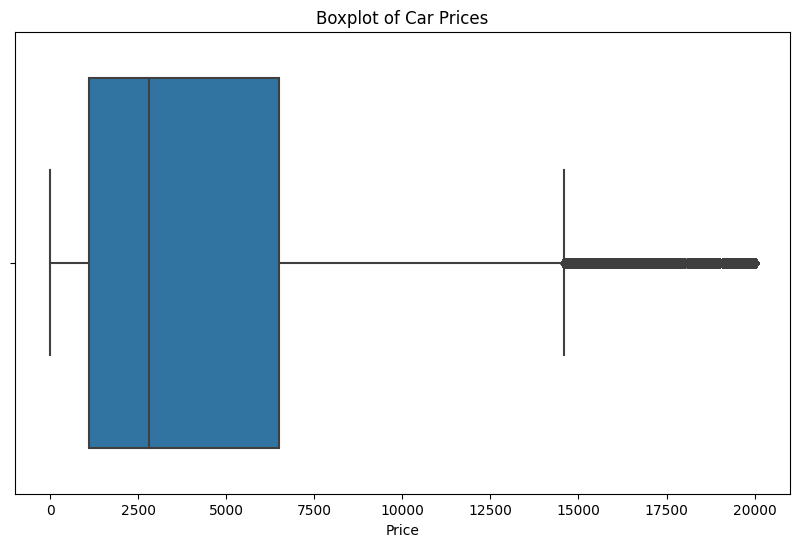

In [28]:
# Plot a Boxplot for the 'price' column
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Price')
plt.title('Boxplot of Car Prices')
plt.show()

This boxplot is right-skewed, showing a higher frequency of lower prices for cars in this dataset that stretches to some higher extreme values. This could make sense considering most cars are depreciating assets and would cluster around lower prices at resale, while some specific brands and models are luxury or can be considered "vintage" or collectors' items with a higher value. 

In [29]:
# Print a sample of records showing high outlier price values
price_outliers = df.nlargest(20, 'Price')
print(price_outliers)

       Price  VehicleType  RegistrationYear  Gearbox  Power      Model  \
1515   20000        sedan              2010     auto  239.0         a6   
1586   20000        sedan              2014     auto  184.0       leon   
2128   20000        sedan              2014   manual  135.0       ceed   
3728   20000        sedan              2011     auto  265.0   c_klasse   
6286   20000        sedan              2009     auto  272.0   e_klasse   
6863   20000        coupe              2002  unknown  110.0      other   
8441   20000        wagon              2010   manual  204.0        3er   
8679   20000          suv              1975   manual   44.0      other   
9335   20000        coupe              2009   manual  179.0         a5   
10153  20000  convertible              2006   manual  265.0    z_reihe   
10247  20000        sedan              2010     auto  184.0        5er   
11325  20000          suv              2008     auto  290.0    cayenne   
11378  20000        sedan             

As shown in the sample, while a few records are for mid/lower range brands such as Kia or Chrysler, most of these high prices are for high-end brands like Porche, Audi, or BMW. Though these values appear in the boxplot as outliers, the prices seem reasonable for the brands and they are likely valid in this dataset so it's best to keep them for model training. 

The boxplot above also shows that the minimum Price is zero. This doesn't make sense as a valid price, and is likely a typo or placeholder for "unknown". 

In [30]:
# Count number of records of 0 in the 'Price' column
(df['Price'] == 0).sum()

9493

This is less than 3% of the dataset and there isn't a reliable way to correct these, so best to drop them.

In [31]:
# Drop rows with 0
df = df[df['Price'] != 0]

Next we'll examine the distribution of numerical features.

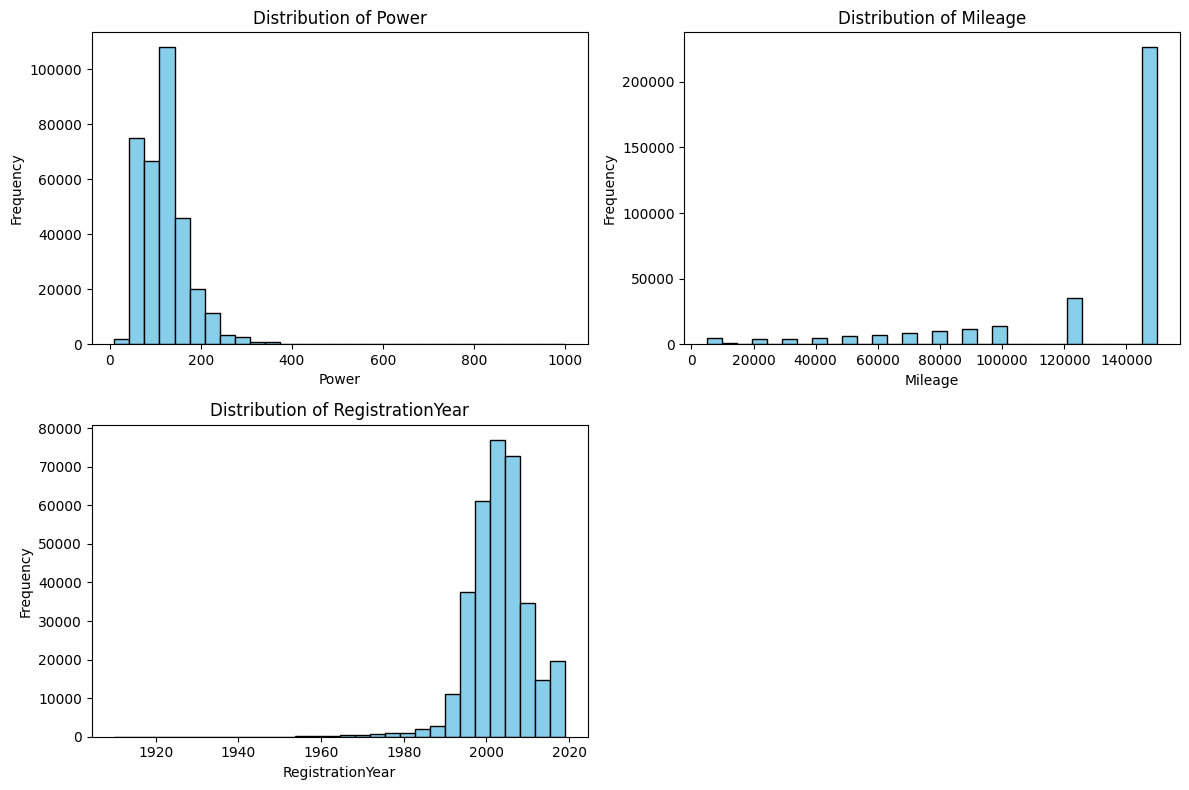

In [32]:

numerical_features = ['Power', 'Mileage', 'RegistrationYear']

# Plotting distributions
plt.figure(figsize=(12, 8))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[feature], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


The distribution of Power is right-skewed with the highest concentration around 100, which makes sense considering zeroes were changes to the mode. 

Mileage shows a left-skewed distribution. The majority of vehicles have high mileage, around 150,000 km, which makes sense for a used car app.

Registration Year is left-skewed, centered primarily around 1995-2010. Most of the cars are moderately old, which fewer cars that are very old or very new. 

Next we'll plot bar charts for the categorical features.

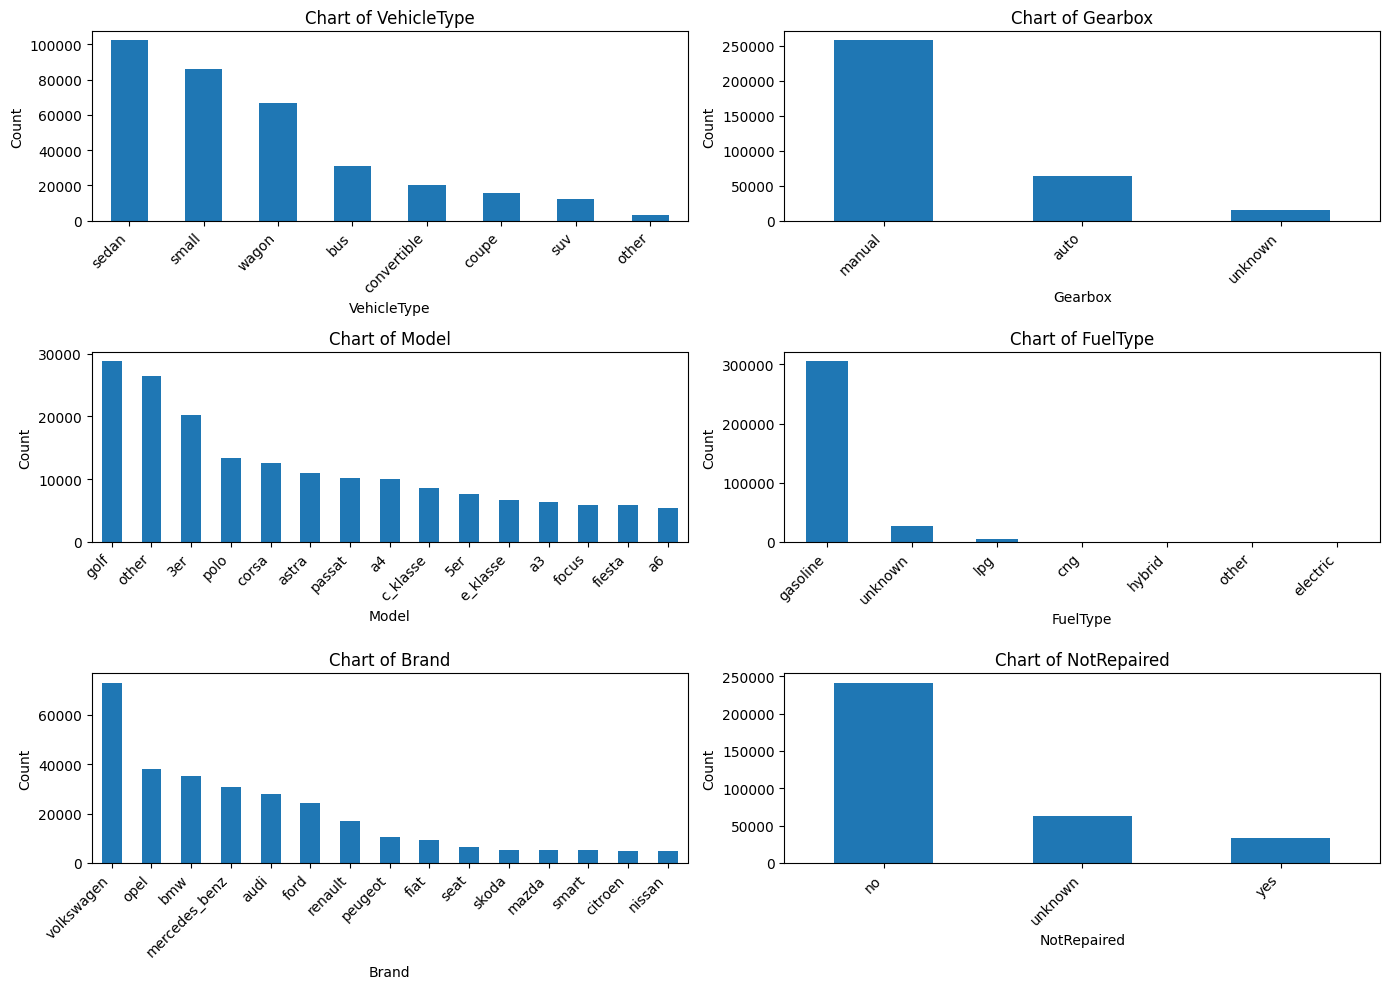

In [33]:
# Define categorical features
categorical_features = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']

# Plot features
plt.figure(figsize=(14, 10))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)
    
    # Get counts
    counts = df[feature].value_counts().head(15)  # limit to top 15 for readability
    
    counts.plot(kind='bar')
    
    plt.title(f'Chart of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Nothing unexpected is emerging in these charts. There is a very high amount of Volkswagens compared to other car brands, but this can be explained by Volskwagen's relatively high inventory levels and high lease volume leading to a lot of vehicles being rturned and sold as used. Most of the cars on the app are not repaired, use gasoline, and are manual transmission. There is a large amount of unknown models.

Overall, this data seems to reflect realistic market scenarios. Finally, we'll look at some summary statistics and correlation of features with the target value.

In [34]:
# Show summary statistics of data
df.describe()

,Price,RegistrationYear,Power,Mileage
count,337196.000000,337196.000000,337196.000000,337196.000000
mean,4591.273666,2003.098833,119.441043,128543.799452
std,4525.641145,7.220104,51.977075,37147.283233
min,1.000000,1910.000000,10.000000,5000.000000
25%,1200.000000,1999.000000,82.000000,125000.000000
50%,2900.000000,2003.000000,110.000000,150000.000000
75%,6500.000000,2008.000000,143.000000,150000.000000
max,20000.000000,2019.000000,1000.000000,150000.000000


In [35]:
# Show correlation of numerical categories
df.select_dtypes(include=['number']).corr()

,Price,RegistrationYear,Power,Mileage
Price,1.000000,0.391930,0.487874,-0.361183
RegistrationYear,0.391930,1.000000,0.102662,-0.203135
Power,0.487874,0.102662,1.000000,0.091439
Mileage,-0.361183,-0.203135,0.091439,1.000000


There is a large gap between the mean and median price in this right-skewed distribution. There is wide variability in prices, which means many different segments. Mileage is heavily capped, which means it may be less predictive.

In terms of correlation, power seems to be the most predictive--higher horsepower means higher price, which makes sense. Registration year is almost as predictive, where newer cars have a higher price which also makes sense. Mileage has a negative correlation with price, and the correlation is weaker than the other two features which makes sense given the cap at 150K.

## Model preparation

We are going to train six models for predicting the price of used cars: Decision Tree, Random Forest, Linear Regression, and three gradient boost models (Catboost, LightGBM, and XGBoost). Some of the models need feature scaling and encoding while some do not, so I'm going to set up preprocessing pipelines to prep the dataset correctly for each model to train.

We'll use OHE for XGBoost per instructions and for Linear Regression as well, but because of the high cardinality of the categorical data, we'll do ordinal encoding for the tree models.

In [36]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Price' in numerical_cols:
    numerical_cols.remove('Price')

# Split data
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Pipeline 1: Linear Regression (OHE + scaling)
pipeline_linear = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse=True), categorical_cols)
])


# Pipeline 2: Decision Tree + Random Forest (Ordinal Encoding, NO scaling)
pipeline_tree = ColumnTransformer([
    ('num', 'passthrough', numerical_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
])


# Pipeline 3: XGBoost (OHE, no scaling)
pipeline_xgboost = ColumnTransformer([
    ('num', 'passthrough', numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse=True), categorical_cols)
])


# LightGBM native categorical setup
X_train_lgbm_native = X_train.copy()
X_val_lgbm_native = X_val.copy()
X_test_lgbm_native = X_test.copy()

for col in categorical_cols:
    X_train_lgbm_native[col] = X_train_lgbm_native[col].astype('category')
    X_val_lgbm_native[col] = X_val_lgbm_native[col].astype('category')
    X_test_lgbm_native[col] = X_test_lgbm_native[col].astype('category')


# Fit and transform datasets

# Linear Regression
X_train_linear = pipeline_linear.fit_transform(X_train)
X_test_linear = pipeline_linear.transform(X_test)
X_val_linear = pipeline_linear.transform(X_val)

# Decision Tree + Random Forest
X_train_tree = pipeline_tree.fit_transform(X_train)
X_test_tree = pipeline_tree.transform(X_test)
X_val_tree = pipeline_tree.transform(X_val)


# XGBoost
X_train_xgboost = pipeline_xgboost.fit_transform(X_train)
X_test_xgboost = pipeline_xgboost.transform(X_test)
X_val_xgboost = pipeline_xgboost.transform(X_val)



Now the data is set up and ready to use for model training. It's now time to train our models. We'll start with the Decision Tree, Random Forest and Linear Regression models.

## Model training

We'll start by training our decision tree model. For each model, we'll be tracking how much time it takes to train and scoring using the RMSE metric.

We'll use Grid Search to tune hyperparameters.

In [37]:
%%time

# Set up model
dt = DecisionTreeRegressor(random_state=19)

# Set up grid for tuning
param_grid_dt = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring='neg_root_mean_squared_error',
    cv=2,
    n_jobs=1,
    verbose=2
)

grid_search_dt.fit(X_train_tree, y_train)

best_dt_model = grid_search_dt.best_estimator_
best_dt_result = -grid_search_dt.best_score_
best_dt_params = grid_search_dt.best_params_

print("Best Decision Tree RMSE:", best_dt_result)
print("Best Decision Tree parameters:", best_dt_params)

Fitting 2 folds for each of 36 candidates, totalling 72 fits
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=10; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=10; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=5, min_samples_split=2; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=5, min_samples_split=2; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=5, min_samples_split=5; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=5, min_samples_split=5; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=5, min_samples_split=10; total time=   0.2s
[CV] END max_depth=5, min_samples_

Next we'll train a Random Forest model.

In [38]:
%%time

# Set up model
rf = RandomForestRegressor(random_state=19)

# Set up grid for tuning
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 14]
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=2,
    n_jobs=1,
    verbose=2
)

grid_search_rf.fit(X_train_tree, y_train)

best_rf_model = grid_search_rf.best_estimator_
best_rf_result = -grid_search_rf.best_score_
best_rf_params = grid_search_rf.best_params_

print("Best Random Forest RMSE:", best_rf_result)
print("Best Random Forest parameters:", best_rf_params)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END ......................max_depth=10, n_estimators=50; total time=  10.0s
[CV] END ......................max_depth=10, n_estimators=50; total time=   9.7s
[CV] END .....................max_depth=10, n_estimators=100; total time=  19.3s
[CV] END .....................max_depth=10, n_estimators=100; total time=  20.0s
[CV] END ......................max_depth=14, n_estimators=50; total time=  12.4s
[CV] END ......................max_depth=14, n_estimators=50; total time=  12.8s
[CV] END .....................max_depth=14, n_estimators=100; total time=  25.6s
[CV] END .....................max_depth=14, n_estimators=100; total time=  25.7s
Best Random Forest RMSE: 1775.4698107159643
Best Random Forest parameters: {'max_depth': 14, 'n_estimators': 100}
CPU times: user 3min 4s, sys: 229 ms, total: 3min 4s
Wall time: 3min 5s


Random Forest definitely took longer to train than the Decision Tree, but did perform better.

Next we'll train a Linear Regression model. 

In [39]:

%%time
# Set up model
lr = LinearRegression()

lr.fit(X_train_linear, y_train)

# Predictions
y_pred_train = lr.predict(X_train_linear)
y_pred_val = lr.predict(X_val_linear)

# RMSE
train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
val_rmse = mean_squared_error(y_val, y_pred_val) ** 0.5

print("Train RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)


Train RMSE: 2700.0623580514443
Validation RMSE: 2797.379189263623
CPU times: user 10.6 s, sys: 26.3 s, total: 37 s
Wall time: 18.5 s


Unsurprisingly, the RMSE on Linear Regression is much higher. This primarily serves as a sanity check for our other models.

Now, we'll move into training our three gradient boosting models. We'll start with XGBoost.

In [40]:
%%time

# Train and fit model
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=19,
    n_jobs=1,
    verbosity=0
)
# Set up grid for tuning
param_grid_xgb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='neg_root_mean_squared_error',
    cv=2,
    n_jobs=1,
    verbose=2
)

grid_search_xgb.fit(X_train_xgboost, y_train)

best_xgb_model = grid_search_xgb.best_estimator_
best_xgb_rmse = -grid_search_xgb.best_score_
best_xgb_params = grid_search_xgb.best_params_

print("Best XGBoost CV RMSE:", best_xgb_rmse)
print("Best XGBoost parameters:", best_xgb_params)

y_pred_val_xgb = best_xgb_model.predict(X_val_xgboost)
val_rmse_xgb = mean_squared_error(y_val, y_pred_val_xgb) ** 0.5

print("XGBoost Validation RMSE:", val_rmse_xgb)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8; total time=   6.2s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8; total time=   6.2s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=1.0; total time=   5.4s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=1.0; total time=   5.0s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, subsample=0.8; total time=  15.3s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, subsample=0.8; total time=  15.4s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, subsample=1.0; total time=  13.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, subsample=1.0; total time=  13.1s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, subsample=0.8; total time=   8.6s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, subsample=0.8; total time=   8.4s

So far this is our best scoring model! Finally, we'll train CatBoost and LightGBM.

In [41]:
%%time

# Train CatBoost model
cat_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=19,
    verbose=0
)
# Set up grid for tuning
param_grid_cat = {
    'iterations': [100, 300],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6]
}

grid_search_cat = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid_cat,
    scoring='neg_root_mean_squared_error',
    cv=2,
    n_jobs=1,
    verbose=2
)

grid_search_cat.fit(
    X_train,
    y_train,
    cat_features=categorical_cols
)

best_cat_model = grid_search_cat.best_estimator_
best_cat_rmse = -grid_search_cat.best_score_
best_cat_params = grid_search_cat.best_params_

print("Best CatBoost CV RMSE:", best_cat_rmse)
print("Best CatBoost parameters:", best_cat_params)

y_pred_val_cat = best_cat_model.predict(X_val)
val_rmse_cat = mean_squared_error(y_val, y_pred_val_cat) ** 0.5

print("CatBoost Validation RMSE:", val_rmse_cat)

Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV] END ........depth=4, iterations=100, learning_rate=0.05; total time=   3.3s
[CV] END ........depth=4, iterations=100, learning_rate=0.05; total time=   3.2s
[CV] END .........depth=4, iterations=100, learning_rate=0.1; total time=   3.2s
[CV] END .........depth=4, iterations=100, learning_rate=0.1; total time=   3.2s
[CV] END ........depth=4, iterations=300, learning_rate=0.05; total time=  22.4s
[CV] END ........depth=4, iterations=300, learning_rate=0.05; total time=  22.0s
[CV] END .........depth=4, iterations=300, learning_rate=0.1; total time=  23.0s
[CV] END .........depth=4, iterations=300, learning_rate=0.1; total time=  23.1s
[CV] END ........depth=6, iterations=100, learning_rate=0.05; total time=   4.3s
[CV] END ........depth=6, iterations=100, learning_rate=0.05; total time=   4.4s
[CV] END .........depth=6, iterations=100, learning_rate=0.1; total time=   4.3s
[CV] END .........depth=6, iterations=100, learni

In [42]:
%%time

# Base model
lgbm = LGBMRegressor(
    objective='regression',
    random_state=19,
    n_jobs=1,
    verbose=-1
)

# Set up grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'num_leaves': [31, 63]
}

grid_search_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=2,
    n_jobs=1,
    verbose=2
)

grid_search_lgbm.fit(
    X_train_lgbm_native,
    y_train,
    categorical_feature=categorical_cols
)

best_lgbm_model = grid_search_lgbm.best_estimator_
best_lgbm_rmse = -grid_search_lgbm.best_score_
best_lgbm_params = grid_search_lgbm.best_params_

print("Best CV RMSE:", best_lgbm_rmse)
print("Best parameters:", best_lgbm_params)

# Validation performance
y_pred_val_lgbm = best_lgbm_model.predict(X_val_lgbm_native)

val_rmse_lgbm = mean_squared_error(y_val, y_pred_val_lgbm) ** 0.5

print("Validation RMSE:", val_rmse_lgbm)

Fitting 2 folds for each of 16 candidates, totalling 32 fits


/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, num_leaves=31; total time=   1.4s


/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, num_leaves=31; total time=   1.4s


...

[CV] END learning_rate=0.1, max_depth=6, n_estimators=300, num_leaves=63; total time=   4.5s


/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


[CV] END learning_rate=0.1, max_depth=6, n_estimators=300, num_leaves=63; total time=   4.4s


/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


Best CV RMSE: 1703.2951578506884
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'num_leaves': 63}
Validation RMSE: 1650.3786416350622
CPU times: user 1min 32s, sys: 207 ms, total: 1min 33s
Wall time: 1min 33s


Our boosting models are all performing comparably well without taking too much time. Now it's time to run a final side-by-side comparison on the best version of each model.

## Model analysis

To analyse our models, we'll refit preprocessing on the combined training and validation sets and run the version of each model type with the best parameters on the test set. We'll look at the RMSE on the test set, training time, and prediction time for each model to ultimately choose the one that is the best fit for Rusty Bargains' criteria: quality and speed.

We'll start by preparing for final training.

In [43]:
# Combine training and validation sets for final training
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

# Refit preprocessing on training + validation

# For Linear Regression: OHE + scaling
X_train_final_linear = pipeline_linear.fit_transform(X_train_final)
X_test_linear_final = pipeline_linear.transform(X_test)

# For Decision Tree + Random Forest: ordinal encoding, no scaling
X_train_final_tree = pipeline_tree.fit_transform(X_train_final)
X_test_tree_final = pipeline_tree.transform(X_test)

# For XGBoost: OHE, no scaling
X_train_final_xgboost = pipeline_xgboost.fit_transform(X_train_final)
X_test_xgboost_final = pipeline_xgboost.transform(X_test)

# Prepare native categorical data for CatBoost

X_train_final_cat = X_train_final.copy()
X_test_cat_final = X_test.copy()

for col in categorical_cols:
    X_train_final_cat[col] = X_train_final_cat[col].astype(str)
    X_test_cat_final[col] = X_test_cat_final[col].astype(str)

# Prepare native categorical data for LightGBM

X_train_final_lgbm = X_train_final.copy()
X_test_lgbm_final = X_test.copy()

for col in categorical_cols:
    X_train_final_lgbm[col] = X_train_final_lgbm[col].astype('category')
    X_test_lgbm_final[col] = X_test_lgbm_final[col].astype('category')

Now we'll set up the final six models using the best parameters tuned above.

In [44]:

# Define RMSE function
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

# Model setup
models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "X_train": X_train_final_linear,
        "X_test": X_test_linear_final
    },

    "Decision Tree": {
        "model": DecisionTreeRegressor(
            random_state=19,
            **best_dt_params
        ),
        "X_train": X_train_final_tree,
        "X_test": X_test_tree_final
    },

    "Random Forest": {
        "model": RandomForestRegressor(
            random_state=19,
            n_jobs=1,
            **best_rf_params
        ),
        "X_train": X_train_final_tree,
        "X_test": X_test_tree_final
    },

    "XGBoost": {
        "model": XGBRegressor(
            objective='reg:squarederror',
            random_state=19,
            n_jobs=1,
            verbosity=0,
            **best_xgb_params
        ),
        "X_train": X_train_final_xgboost,
        "X_test": X_test_xgboost_final
    },

    "CatBoost": {
        "model": CatBoostRegressor(
            loss_function='RMSE',
            random_seed=19,
            verbose=0,
            **best_cat_params
        ),
        "X_train": X_train_final_cat,
        "X_test": X_test_cat_final
    },

    "LightGBM": {
        "model": LGBMRegressor(
            objective='regression',
            random_state=19,
            n_jobs=1,
            verbose=-1,
            **best_lgbm_params
        ),
        "X_train": X_train_final_lgbm,
        "X_test": X_test_lgbm_final
    }
}

Now it's time to train, predict, time, and evaluate our final models.

In [45]:
# Define function for all models
results = []
# Train models
for model_name, item in models.items():
    model = item["model"]
    X_train_model = item["X_train"]
    X_test_model = item["X_test"]

    print(f"Training {model_name}...")

    start_train = time.perf_counter()

    if model_name == "CatBoost":
        model.fit(
            X_train_model,
            y_train_final,
            cat_features=categorical_cols
        )
    elif model_name == "LightGBM":
        model.fit(
            X_train_model,
            y_train_final,
            categorical_feature=categorical_cols
        )
    else:
        model.fit(X_train_model, y_train_final)

    # Time models
    train_time = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    y_pred_test = model.predict(X_test_model)
    pred_time = time.perf_counter() - start_pred

    # Evaluate using rmse
    test_rmse = rmse(y_test, y_pred_test)

    results.append({
        "Model": model_name,
        "Training Time (sec)": train_time,
        "Prediction Time on Test Set (sec)": pred_time,
        "Prediction Time per Row (sec)": pred_time / len(X_test),
        "Test RMSE": test_rmse
    })

    print(f"{model_name} complete.")

Training Linear Regression...
Linear Regression complete.
Training Decision Tree...
Decision Tree complete.
Training Random Forest...
Random Forest complete.
Training XGBoost...
XGBoost complete.
Training CatBoost...
CatBoost complete.
Training LightGBM...


/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


LightGBM complete.


Now we'll create a table to easily do a side-by-side comparison.

In [46]:
# Create comparison table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Test RMSE").reset_index(drop=True)

results_df

# Format table
results_df.style.format({
    "Training Time (sec)": "{:.3f}",
    "Prediction Time on Test Set (sec)": "{:.3f}",
    "Prediction Time per Row (sec)": "{:.8f}",
    "Test RMSE": "{:.2f}"
})

,Model,Training Time (sec),Prediction Time on Test Set (sec),Prediction Time per Row (sec),Test RMSE
0,LightGBM,5.171,0.800,0.00001582,1681.45
1,XGBoost,48.830,0.445,0.00000879,1717.09
2,CatBoost,83.195,0.193,0.00000381,1740.79
3,Random Forest,53.578,0.572,0.00001130,1755.56
4,Decision Tree,1.053,0.009,0.00000018,1888.01
5,Linear Regression,17.774,0.001,0.00000002,2834.56


As expected, our Linear Regression was the worst of the bunch in RMSE, though it was the fastest. Random Forest performed better, but took a longer time to train and predict. Of the five models we trained, tuned, and tested, LightGBM performed the best in terms of quality. However, it was the slowest of all the models.

## Conclusion

After training, tuning, and evaluating different models, the gradient boosting models emerged as the best models in terms of RMSE.

Of the gradient boosting models, though LightGBM performed the best on RMSE, based on this analysis I recommend going with CatBoost as the final model. Not only did CatBoost perform the fastest of the three gradient boosting models, it also is best equipped to natively handle messy and missing data, whether it be numerical or categorical. This makes it the best product choice for real-world, messy data, and its RMSE is only slightly higher than LightGBM. The speed (4x faster than LightGBM) not only makes for a better user experience, but also will mean lower server cost and easier scaling.

Given the minimal difference in predictive performance, CatBoost provides the best balance of accuracy, robustness, and speed for this use case.